In [124]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [125]:
url_dados = 'https://raw.githubusercontent.com/RafaelGirardin/Modelo_Flow_2026/refs/heads/master/Dataset_Modelo_Flow_2026.csv'

dataset_original = pd.read_csv(url_dados)
type(dataset_original)
dataset_original.info()
qtd_linhas_dataset_original = dataset_original.shape[0]
qtd_colunas_dataset_original = dataset_original.shape[1]
dataset_original.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39055 entries, 0 to 39054
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CD_ALOCACAO          39055 non-null  int64  
 1   DATA_SAIDA           39055 non-null  object 
 2   DATA_CHEGADA         39055 non-null  object 
 3   CD_TIPOCARGA         39055 non-null  int64  
 4   EXCESSO_CAMINHAO     39055 non-null  int64  
 5   COLHEDORAS_OP        39055 non-null  int64  
 6   COLHEDORAS_PA        39055 non-null  int64  
 7   TRANSBORDOS_OP       39055 non-null  int64  
 8   TRANSBORDOS_PA       39055 non-null  int64  
 9   QTD_CAMINHAO_INDO    39055 non-null  int64  
 10  TURNO                39055 non-null  int64  
 11  CD_FAZENDA           39055 non-null  int64  
 12  DIFICULDADE_CHEGADA  39055 non-null  float64
 13  CD_FAZENDA_LIBERADA  39055 non-null  int64  
 14  HORAS_VIAGEM         39055 non-null  float64
dtypes: float64(2), int64(11), object(2)


(39055, 15)

In [126]:
dataset_original.describe()

,CD_ALOCACAO,CD_TIPOCARGA,EXCESSO_CAMINHAO,COLHEDORAS_OP,COLHEDORAS_PA,TRANSBORDOS_OP,TRANSBORDOS_PA,QTD_CAMINHAO_INDO,TURNO,CD_FAZENDA,DIFICULDADE_CHEGADA,CD_FAZENDA_LIBERADA,HORAS_VIAGEM
count,39055.000000,39055.0,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000,39055.000000
mean,218907.655563,10.0,0.346844,3.917296,0.694661,8.002535,0.702650,0.943746,0.484701,62.294303,0.090221,13062.437102,1.607167
std,19640.772904,0.0,0.475972,0.795769,0.750341,1.353191,0.885402,0.815263,0.499772,37.061762,0.028496,1506.773649,0.712367
min,188579.000000,10.0,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.043725,10763.000000,0.400278
25%,199920.500000,10.0,0.000000,3.000000,0.000000,7.000000,0.000000,0.000000,0.000000,34.000000,0.071774,11883.000000,1.067500
50%,217445.000000,10.0,0.000000,4.000000,1.000000,8.000000,0.000000,1.000000,0.000000,58.000000,0.079910,12723.000000,1.506111
75%,236836.000000,10.0,1.000000,4.000000,1.000000,9.000000,1.000000,1.000000,1.000000,79.000000,0.100934,14423.000000,2.035278
max,256586.000000,10.0,1.000000,7.000000,5.000000,16.000000,9.000000,11.000000,1.000000,147.000000,0.190368,16309.000000,7.970000


In [ ]:
ds_em_preparacao = dataset_original.loc[:, ['CD_TIPOCARGA', 'EXCESSO_CAMINHAO','COLHEDORAS_OP', 'TRANSBORDOS_OP','TURNO','DIFICULDADE_CHEGADA', 'HORAS_VIAGEM']]

ds_em_preparacao.head()

In [158]:
ds_em_preparacao.head()

,CD_TIPOCARGA,EXCESSO_CAMINHAO,COLHEDORAS_OP,TRANSBORDOS_OP,QTD_CAMINHAO_INDO,TURNO,DIFICULDADE_CHEGADA,HORAS_VIAGEM
0,10,1,2,1,1,0,0.190368,0.475278
1,10,0,2,1,1,0,0.190368,0.407500
2,10,0,2,3,1,0,0.190368,0.570278
3,10,0,2,3,0,0,0.190368,1.060278
4,10,0,2,2,3,0,0.190368,0.404444


In [159]:
from sklearn.preprocessing import MinMaxScaler

ds_em_preparacao_encoded = pd.get_dummies(ds_em_preparacao, columns=['CD_TIPOCARGA'], drop_first=True)

scaler = MinMaxScaler()
ds_em_preparacao_encoded['COLHEDORAS_OP'] = scaler.fit_transform(ds_em_preparacao_encoded[['COLHEDORAS_OP']])
ds_em_preparacao_encoded['TRANSBORDOS_OP'] = scaler.fit_transform(ds_em_preparacao_encoded[['TRANSBORDOS_OP']])
ds_em_preparacao_encoded['DIFICULDADE_CHEGADA'] = scaler.fit_transform(ds_em_preparacao_encoded[['DIFICULDADE_CHEGADA']])

ds_preparado = ds_em_preparacao_encoded
ds_preparado.head()

,EXCESSO_CAMINHAO,COLHEDORAS_OP,TRANSBORDOS_OP,QTD_CAMINHAO_INDO,TURNO,DIFICULDADE_CHEGADA,HORAS_VIAGEM
0,1,0.166667,0.000000,1,0,1.0,0.475278
1,0,0.166667,0.000000,1,0,1.0,0.407500
2,0,0.166667,0.133333,1,0,1.0,0.570278
3,0,0.166667,0.133333,0,0,1.0,1.060278
4,0,0.166667,0.066667,3,0,1.0,0.404444


In [160]:
array = ds_preparado.values
X = array[:,0:5]
y = array[:,5]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.125, random_state=7) # faz a divisão

num_particoes = 10
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7)

LR: MSE 0.03 (0.00) - RMSE 0.17
Ridge: MSE 0.03 (0.00) - RMSE 0.17
Lasso: MSE 0.04 (0.00) - RMSE 0.19
KNN: MSE 0.03 (0.00) - RMSE 0.18
CART: MSE 0.03 (0.00) - RMSE 0.16
SVM: MSE 0.03 (0.00) - RMSE 0.17


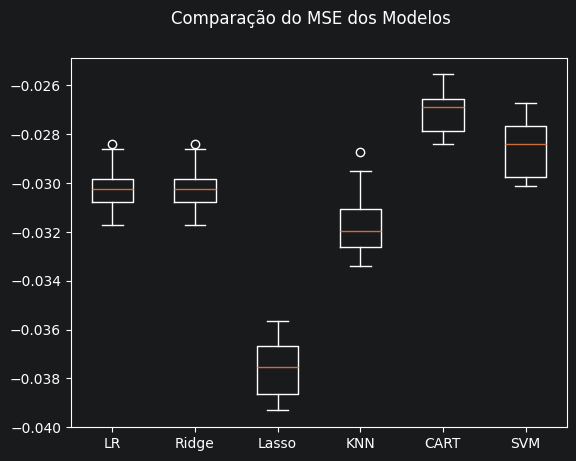

In [161]:
np.random.seed(7)

models = []
results = []
names = []

models.append(('LR', LinearRegression()))
models.append(('Ridge', Ridge()))
models.append(('Lasso', Lasso()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVM', SVR()))

for name, model in models:
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
  results.append(cv_results)
  names.append(name)
  # imprime MSE, desvio padrão do MSE e RMSE dos 10 resultados da validação cruzada
  msg = "%s: MSE %0.2f (%0.2f) - RMSE %0.2f" % (name, abs(cv_results.mean()), cv_results.std(), np.sqrt(abs(cv_results.mean())))
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação do MSE dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [166]:
# Criando um modelo com todo o conjunto de treino
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(X_test)
# Estimando o MSE e o RMSE no conjunto de teste
mse = mean_squared_error(y_test, predictions)
print("MSE %0.2f" % mse)
print("RMSE %0.2f" % np.sqrt(abs(mse)))

[0.  0.5 0.4 1.  1. ]
0.23720725444397633
0.24733246780236903
MSE 0.03
RMSE 0.16
